In [4]:
# ==========================================
# 1. IMPORT LIBRARIES & SETUP
# ==========================================

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

## DATA LOADING

In [2]:
articles=pd.read_parquet('data/articles_processed.parquet')
customers=pd.read_parquet('data/customers_processed.parquet')
transactions=pd.read_parquet('data/transactions_processed.parquet')


In [3]:
#================================================================================
#                  TRAIN-VALIDATION SPLIT
#================================================================================

last_date=transactions['t_dat'].max()
val_start=last_date-pd.Timedelta(days=6)
train=transactions[transactions['t_dat']<val_start]
val=transactions[transactions['t_dat']>=val_start]

In [7]:
#================================================================================
#                      Metrics
#================================================================================

total_catalog_items = articles['article_id'].nunique()
sales_series = transactions['article_id'].value_counts()

total_sales = len(transactions)

novelty_dict = (
    (-np.log2(sales_series / total_sales)).to_dict()
)


def evaluate_baseline(predictions, actuals, total_catalog_items, novelty_dict, k=12):
    precisions, recalls, map_scores, novelty_scores, ndcg_scores = [], [], [], [], []
    recommended_unique_items = set()

    #discounts vector for NDCG@K speedup
    discounts = np.log2(np.arange(2, k + 2))

    for user_id, recs in predictions.items():
        if user_id not in actuals:
            continue

        true_items = set(actuals[user_id])
        if len(true_items) == 0:
            continue

        top_k_recs = recs[:k]

        # 1. Precision & Recall
        hits = len(set(top_k_recs) & true_items)
        precisions.append(hits / k)
        recalls.append(hits / len(true_items))

        # 2. Average Precision (MAP@K)
        score = 0.0
        num_hits = 0.0
        for i, p in enumerate(top_k_recs):
            if p in true_items and p not in top_k_recs[:i]:
                num_hits += 1.0
                score += num_hits / (i + 1.0)
        map_scores.append(score / min(len(true_items), k))

        # 3. NDCG@K
        hits_binary = [1 if p in true_items else 0 for p in top_k_recs]
        if any(hits_binary):
            dcg = np.sum(hits_binary / discounts[:len(hits_binary)])
            ideal_hits = sorted(hits_binary, reverse=True)
            idcg = np.sum(ideal_hits / discounts[:len(ideal_hits)])
            ndcg_scores.append(dcg / idcg)
        else:
            ndcg_scores.append(0.0)

        # 4. Novelty (Self-Information)
        user_novelty = np.mean([novelty_dict.get(item, 20.0) for item in top_k_recs])
        novelty_scores.append(user_novelty)

        # 5. Coverage
        recommended_unique_items.update(top_k_recs)

    return {
        f"Precision@{k}": np.mean(precisions),
        f"Recall@{k}": np.mean(recalls),
        f"MAP@{k}": np.mean(map_scores),
        f"NDCG@{k}": np.mean(ndcg_scores),
        f"Novelty@{k}": np.mean(novelty_scores),
        "Coverage": len(recommended_unique_items) / total_catalog_items,
    }

## BASELINE 1: Global Popularity

In [9]:
top12_popular = train['article_id'].value_counts().head(12).index.tolist()
actuals = val.groupby('customer_idx')['article_id'].unique().to_dict()

predictions = {user: top12_popular for user in actuals.keys()}

pop_results = evaluate_baseline(
    predictions=predictions,
    actuals=actuals,
    total_catalog_items=total_catalog_items,
    novelty_dict=novelty_dict,
    k=12
)

print("=== GLOBAL POPULARITY BASELINE RESULTS ===")
for metric, value in pop_results.items():
    print(f"{metric:<15}: {value:.6f}")

=== GLOBAL POPULARITY BASELINE RESULTS ===
Precision@12   : 0.001975
Recall@12      : 0.007749
MAP@12         : 0.002899
NDCG@12        : 0.010849
Novelty@12     : 10.220784
Coverage       : 0.000114


## BASELINE 2: Recent Popularity

In [14]:
end = train['t_dat'].max()
start = end - pd.Timedelta(days=7)

top12_recent = (
    train[train['t_dat'] >= start]
    .groupby('article_id')
    .size()
    .nlargest(12)
    .index.tolist()
)

actuals = val.groupby('customer_idx')['article_id'].unique().to_dict()
actuals = {user: set(items) for user, items in actuals.items()}


predictions = {user: top12_recent for user in actuals.keys()}

recent_pop_results = evaluate_baseline(
    predictions=predictions,
    actuals=actuals,
    total_catalog_items=total_catalog_items,
    novelty_dict=novelty_dict,
    k=12
)

print("=== RECENT (LAST 7 DAYS) POPULARITY BASELINE RESULTS ===")
for metric, value in recent_pop_results.items():
    print(f"{metric:<15}: {value:.6f}")

=== RECENT (LAST 7 DAYS) POPULARITY BASELINE RESULTS ===
Precision@12   : 0.005757
Recall@12      : 0.025534
MAP@12         : 0.008737
NDCG@12        : 0.029739
Novelty@12     : 13.067054
Coverage       : 0.000114


## BASELINE 3: Repeat Purchases + Recent Popularity fallback

In [15]:

customer_article_counts = (
    train.groupby(['customer_idx', 'article_id'])
    .size()
    .reset_index(name='count')
    .sort_values(['customer_idx', 'count'], ascending=[True, False])
)

customer_history = customer_article_counts.groupby('customer_idx')['article_id'].apply(list).to_dict()

def predict_user(c_idx):
    own = customer_history.get(c_idx, [])
    if len(own) < 12:
        fill = [p for p in top12_recent if p not in own]
        own = own + fill[:12 - len(own)]
    return own[:12]

actuals = val.groupby('customer_idx')['article_id'].unique().to_dict()
actuals = {user: set(items) for user, items in actuals.items()}

predictions = {c: predict_user(c) for c in actuals.keys()}

repeat_pop_results = evaluate_baseline(
    predictions=predictions,
    actuals=actuals,
    total_catalog_items=total_catalog_items,
    novelty_dict=novelty_dict,
    k=12
)

print("=== REPEAT PURCHASES + RECENT POPULARITY BASELINE RESULTS ===")
for metric, value in repeat_pop_results.items():
    print(f"{metric:<15}: {value:.6f}")

=== REPEAT PURCHASES + RECENT POPULARITY BASELINE RESULTS ===
Precision@12   : 0.004448
Recall@12      : 0.024651
MAP@12         : 0.009703
NDCG@12        : 0.024760
Novelty@12     : 14.335427
Coverage       : 0.563899



## BASELINE 4: Limited History + Recent Popularity

In [18]:

K_HISTORY = 5  

def predict_baseline4(customer_idx):
    own = customer_history.get(customer_idx, [])[:K_HISTORY]
    
    if len(own) < 12:
        fill = [p for p in top12_recent if p not in own]
        own = own + fill[:12 - len(own)]
        
    return own[:12]

actuals = val.groupby('customer_idx')['article_id'].unique().to_dict()
actuals = {user: set(items) for user, items in actuals.items()}

predictions = {c: predict_baseline4(c) for c in actuals.keys()}

b4_results = evaluate_baseline(
    predictions=predictions,
    actuals=actuals,
    total_catalog_items=total_catalog_items,
    novelty_dict=novelty_dict,
    k=12
)

print("=== BASELINE 4 (TOP 5 REPEAT + RECENT POPULARITY) RESULTS ===")
for metric, value in b4_results.items():
    print(f"{metric:<15}: {value:.6f}")

=== BASELINE 4 (TOP 5 REPEAT + RECENT POPULARITY) RESULTS ===
Precision@12   : 0.006369
Recall@12      : 0.032383
MAP@12         : 0.010642
NDCG@12        : 0.032102
Novelty@12     : 13.564771
Coverage       : 0.423869


In [21]:

all_baselines = {
    'Global Popularity': pop_results,
    'Recent Popularity (7d)': recent_pop_results,
    'Repeat + Popularity Fallback': repeat_pop_results,
    'Top 5 Repeat + Popularity': b4_results
}

df_results = pd.DataFrame(all_baselines).T

pd.set_option('display.float_format', lambda x: '%.5f' % x)

print(df_results)

                              Precision@12  Recall@12  MAP@12  NDCG@12  \
Global Popularity                  0.00198    0.00775 0.00290  0.01085   
Recent Popularity (7d)             0.00576    0.02553 0.00874  0.02974   
Repeat + Popularity Fallback       0.00445    0.02465 0.00970  0.02476   
Top 5 Repeat + Popularity          0.00637    0.03238 0.01064  0.03210   

                              Novelty@12  Coverage  
Global Popularity               10.22078   0.00011  
Recent Popularity (7d)          13.06705   0.00011  
Repeat + Popularity Fallback    14.33543   0.56390  
Top 5 Repeat + Popularity       13.56477   0.42387  


<Figure size 1000x500 with 0 Axes>

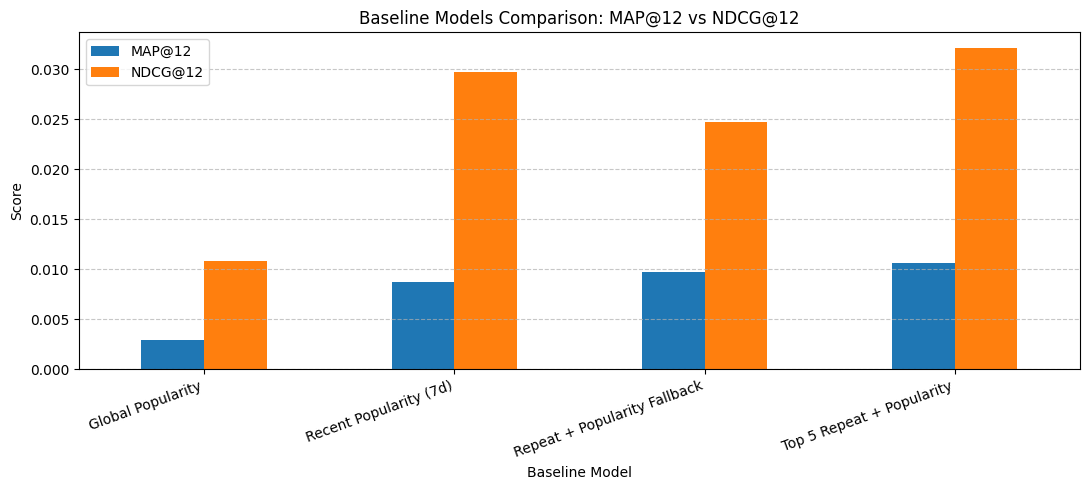

In [22]:

plt.figure(figsize=(10, 5))
df_results[['MAP@12', 'NDCG@12']].plot(kind='bar', figsize=(11, 5))
plt.title('Baseline Models Comparison: MAP@12 vs NDCG@12')
plt.ylabel('Score')
plt.xlabel('Baseline Model')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()